# Diptera wing classification using Topological Data Analysis

Guilherme Vituri F. Pinto [](https://orcid.org/0000-0002-7813-8777) (Universidade Estadual Paulista)  
Sergio UraNorthonApril 26, 2026

We use Topological Data Analysis (TDA) to describe Diptera wing venation and classify specimens at the family level. From 70 binarized wing images representing nine families, we extract two compact persistence summaries: H1 persistence from Vietoris-Rips filtrations of point-cloud samples and H0 persistence from radial filtrations of connected wing images. These 34 topological features are evaluated with a single balanced Random Forest model using repeated stratified 3-fold cross-validation. Because the dataset is imbalanced, performance is summarized primarily with macro-F1, macro-recall, family-level recall, and a row-normalized confusion matrix. We also use a feature-reduction screen to identify a smaller candidate set of topological summaries for biological interpretation.

In [2]:
import Pkg
Pkg.activate(pwd())

using TDAfly: findall_ids
using TDAfly.Preprocessing: connect_pixel_components, image_to_array, image_to_r2, load_wing
using TDAfly.TDA: pd_statistics_extended, radial_filtration, radial_pd_0d, rips_pd_1d
using TDAfly.Analysis: classification_metrics, confusion_matrix, sanitize_feature_matrix
using DataFrames
using DecisionTree
using DecisionTree: apply_forest, build_forest, build_tree
using MetricSpaces: farthest_points_sample
using PersistenceDiagrams: persistence
using Plots: bar, default, display, heatmap, hline!, plot, plot!
using ProgressMeter: @showprogress
using Random: MersenneTwister, shuffle!
using Statistics: mean, std
using StatsPlots: boxplot

# Use raster plots for notebook frontends that may mis-render large vector output.
default(fmt = :png, dpi = 120, size = (720, 460))

<style>
.cell-output-display img,
.quarto-figure img {
  max-width: 100%;
  height: auto;
}
</style>

In [3]:
CV_K = 3
CV_REPEATS = 30
RF_N_TREES = 500
RF_MAX_DEPTH = -1
RF_MIN_SAMPLES_LEAF = 1
RNG_SEED = 20260223
FEATURE_SCREEN_REPEATS = 10
FEATURE_SCREEN_N_TREES = 250
FEATURE_PERFORMANCE_TOLERANCE = 0.01

0.01

## Introduction

Diptera wing venation is a classical taxonomic character: the arrangement of veins and enclosed cells varies among families and provides a natural morphological signature. Topological Data Analysis (TDA) is well suited to this problem because persistent homology summarizes connected components and loops in a way that is less tied to exact pixel coordinates than many raw image descriptors.

We use two complementary filtrations: a Vietoris-Rips filtration on point-cloud samples of each wing, retaining H1 persistence to describe global loops; and a radial filtration on the connected binary wing image, retaining H0 persistence to describe how vein components merge from the center of the wing outward.

The statistical goal is to test whether compact topological summaries carry family-level signal and to identify which summaries are most useful for prediction. To keep the validation aligned with the small and imbalanced dataset, we evaluate one balanced Random Forest model with repeated stratified 3-fold cross-validation and report macro-F1, macro-recall, family-level recall, and the confusion matrix.

## Methods

### Data and preprocessing

All wing images are stored in `images/processed`. File names encode the family and specimen identifier. We standardize family names, remove duplicated files that differ only by spacing or spelling variants, blur each image slightly, crop it, and resize it to 150 pixels in height.

In [4]:
all_paths = sort(readdir("images/processed", join = true))
all_filenames = basename.(all_paths) .|> (x -> replace(x, ".png" => ""))

function extract_family(name)
    family_raw = lowercase(split(name, r"[\s\-]")[1])
    if family_raw in ("bibionidae", "biobionidae")
        return "Bibionidae"
    elseif family_raw in ("sciaridae", "scaridae")
        return "Sciaridae"
    elseif family_raw == "simulidae"
        return "Simuliidae"
    else
        return titlecase(family_raw)
    end
end

function canonical_id(name)
    family = extract_family(name)
    specimen_number = split(name, r"[\s\-]")[end]
    "$(family)-$(specimen_number)"
end

seen = Set{String}()
keep_idx = Int[]
for (i, fname) in enumerate(all_filenames)
    cid = canonical_id(fname)
    if !(cid in seen)
        push!(seen, cid)
        push!(keep_idx, i)
    end
end

paths = all_paths[keep_idx]
species = all_filenames[keep_idx]
families = extract_family.(species)
individuals = map(species) do specimen
    specimen_number = split(specimen, r"[\s\-]")[end]
    string(extract_family(specimen)[1]) * "-" * specimen_number
end

dataset_df = DataFrame(family = families)
family_counts_df = combine(groupby(dataset_df, :family), nrow => :n)
sort!(family_counts_df, :family)

println("Total images after deduplication: $(length(paths))")
println("Number of families: $(length(unique(families)))")
family_counts_df

Total images after deduplication: 70
Number of families: 9

In [5]:
wings = load_wing.(paths, blur = 1.8)
Xs = map(wings) do wing
    image_to_r2(wing; threshold = 0.08, ensure_connected = true, connectivity = 8)
end;

### Topological feature extraction

We compute two persistence diagrams for each wing. First, we sample 750 points from the wing point cloud and compute H1 persistence from the Vietoris-Rips filtration. Second, we construct a connected binary image and compute H0 persistence from the radial filtration.

> **Persistent homology overview**
>
> Persistent homology tracks topological features as a filtration parameter changes. H0 records connected components; H1 records loops. Long-lived features are treated as more stable shape information than short-lived features.

In [6]:
samples = Vector{Any}(undef, length(Xs))
Threads.@threads for i in eachindex(Xs)
    samples[i] = farthest_points_sample(Xs[i], 750)
end

pds_rips = @showprogress "rips_h1" map(samples) do sample
    rips_pd_1d(sample, cutoff = 5, threshold = 200)
end;

In [7]:
function make_connected_array(wing; threshold = 0.08, connectivity = 8)
    rows, cols = size(wing)
    ids = findall_ids(>(threshold), image_to_array(wing))
    ids_conn = connect_pixel_components(ids; connectivity = connectivity)
    A = ones(Float64, rows, cols)
    for p in ids_conn
        A[p[1], p[2]] = 0.0
    end
    A
end

wing_arrays = [make_connected_array(wing) for wing in wings]

pds_radial_h0 = @showprogress "radial_h0" map(wing_arrays) do A
    radial_pd_0d(A)
end;

The plots below show three representative wings, their radial filtration, and the largest persistence values from each retained diagram.


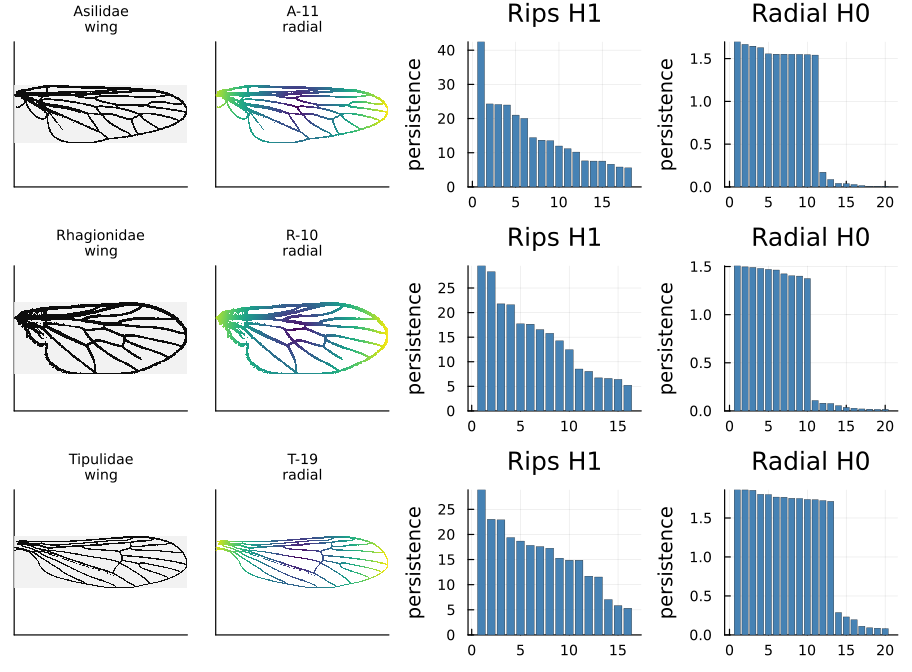

In [8]:
function wing_panel(idx; title_str = "")
    heatmap(
        wing_arrays[idx][end:-1:1, :],
        color = :grays,
        colorbar = false,
        aspect_ratio = :equal,
        xticks = false,
        yticks = false,
        title = title_str,
        titlefontsize = 8,
    )
end

function radial_panel(idx; title_str = "")
    F = radial_filtration(wing_arrays[idx])
    F_display = copy(F)
    F_display[F_display .> 1.5] .= NaN
    heatmap(
        F_display[end:-1:1, :],
        color = :viridis,
        colorbar = false,
        aspect_ratio = :equal,
        xticks = false,
        yticks = false,
        title = title_str,
        titlefontsize = 8,
    )
end

function persistence_bar(values; title_str)
    finite_values = sort([v for v in values if isfinite(v)], rev = true)
    finite_values = finite_values[1:min(20, length(finite_values))]
    if isempty(finite_values)
        return plot(title = title_str, legend = false)
    end
    bar(
        finite_values,
        title = title_str,
        ylabel = "persistence",
        legend = false,
        color = :steelblue,
        linecolor = :black,
        linewidth = 0.25,
    )
end

example_families = sort(unique(families))[[1, cld(length(unique(families)), 2), length(unique(families))]]
example_indices = [findfirst(==(family), families) for family in example_families]

example_plots = Any[]
for idx in example_indices
    push!(example_plots, wing_panel(idx; title_str = "$(families[idx])\nwing"))
    push!(example_plots, radial_panel(idx; title_str = "$(individuals[idx])\nradial"))
    push!(example_plots, persistence_bar(persistence.(pds_rips[idx]); title_str = "Rips H1"))
    radial_persistence = [persistence(x) for x in pds_radial_h0[idx]]
    push!(example_plots, persistence_bar(radial_persistence; title_str = "Radial H0"))
end

plot(example_plots..., layout = (length(example_indices), 4), size = (760, 560))

### Summary statistics

Each persistence diagram is converted into 19 summary statistics. We retain 17 statistics per diagram and exclude skewness and kurtosis because these tail-sensitive summaries are less reliable for small persistence diagrams. This gives 34 features per specimen.

In [9]:
all_stat_names_ext = [
    "count", "max_pers", "total_pers", "total_pers2",
    "q10", "q25", "median", "q75", "q90",
    "entropy", "std_pers",
    "skewness", "kurtosis",
    "median_birth", "median_death", "std_birth", "std_death",
    "mean_midlife", "pers_range"
]

drop_stat_names = Set(["skewness", "kurtosis"])
keep_stat_idx = findall(stat -> !(stat in drop_stat_names), all_stat_names_ext)
stat_names_ext = all_stat_names_ext[keep_stat_idx]

stats_rips_raw = collect(hcat([pd_statistics_extended(pd) for pd in pds_rips]...)')
stats_radial_h0_raw = collect(hcat([pd_statistics_extended(pd) for pd in pds_radial_h0]...)')
stats_rips = stats_rips_raw[:, keep_stat_idx]
stats_radial_h0 = stats_radial_h0_raw[:, keep_stat_idx]

labels = families
X_features = hcat(stats_rips, stats_radial_h0) |> sanitize_feature_matrix
feature_blocks = ["Rips_H1", "Radial_H0"]
feature_names = ["$(block)__$(stat)" for block in feature_blocks for stat in stat_names_ext]

println("Retained statistics per diagram: $(length(stat_names_ext))")
println("Feature matrix: $(size(X_features, 1)) samples x $(size(X_features, 2)) features")

Retained statistics per diagram: 17
Feature matrix: 70 samples x 34 features


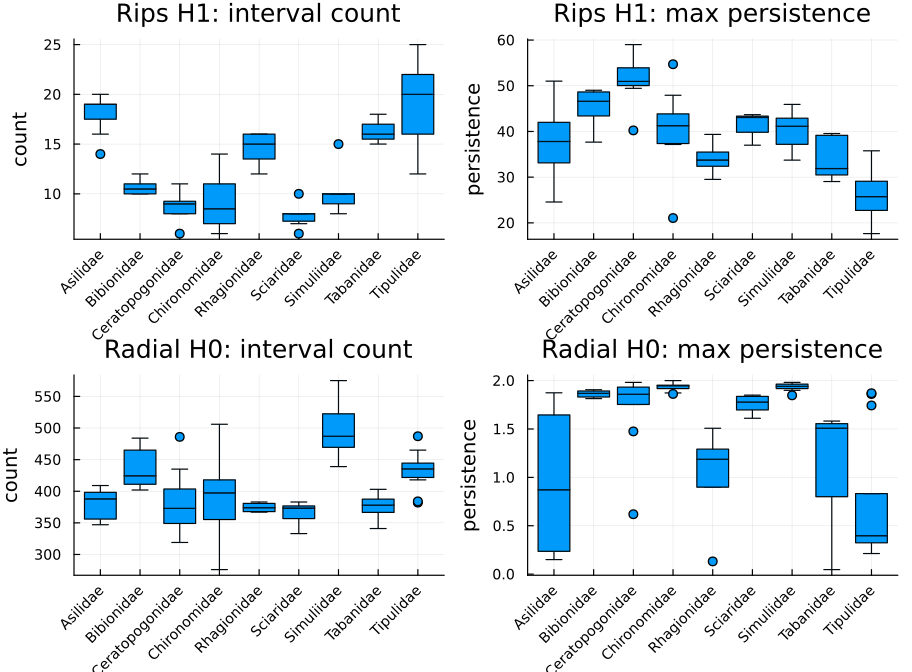

In [10]:
stats_df = DataFrame(
    sample = individuals,
    family = families,
    rips_count = stats_rips[:, 1],
    rips_max_persistence = stats_rips[:, 2],
    radial_count = stats_radial_h0[:, 1],
    radial_max_persistence = stats_radial_h0[:, 2],
)

p1 = boxplot(
    stats_df.family,
    stats_df.rips_count,
    title = "Rips H1: interval count",
    legend = false,
    ylabel = "count",
    xrotation = 45,
)
p2 = boxplot(
    stats_df.family,
    stats_df.rips_max_persistence,
    title = "Rips H1: max persistence",
    legend = false,
    ylabel = "persistence",
    xrotation = 45,
)
p3 = boxplot(
    stats_df.family,
    stats_df.radial_count,
    title = "Radial H0: interval count",
    legend = false,
    ylabel = "count",
    xrotation = 45,
)
p4 = boxplot(
    stats_df.family,
    stats_df.radial_max_persistence,
    title = "Radial H0: max persistence",
    legend = false,
    ylabel = "persistence",
    xrotation = 45,
)
plot(p1, p2, p3, p4, layout = (2, 2), size = (760, 560))

## Classification

We use one classifier: a balanced Random Forest. In each training fold, minority families are upsampled by bootstrap resampling to match the largest family in that fold. Hyperparameters are fixed in advance, so no additional tuning loop is used. The validation procedure is repeated stratified 3-fold cross-validation with 30 repeats.

In [11]:
function stratified_kfolds(labels::Vector{String}; k::Int, rng::MersenneTwister)
    folds = [Int[] for _ in 1:k]
    for cls in sort(unique(labels))
        cls_idx = findall(==(cls), labels)
        shuffle!(rng, cls_idx)
        for (j, idx) in enumerate(cls_idx)
            push!(folds[mod1(j, k)], idx)
        end
    end
    folds
end

function balanced_bootstrap_indices(labels::Vector{String}; rng::MersenneTwister)
    classes = sort(unique(labels))
    target_n = maximum(count(==(cls), labels) for cls in classes)
    idx = Int[]
    for cls in classes
        cls_idx = findall(==(cls), labels)
        append!(idx, rand(rng, cls_idx, target_n))
    end
    shuffle!(rng, idx)
    idx
end

function predict_balanced_rf_fold(
    X_train::Matrix,
    y_train::Vector{String},
    X_test::Matrix;
    n_trees::Int,
    max_depth::Int,
    min_samples_leaf::Int,
    rng::MersenneTwister,
)
    boot_idx = balanced_bootstrap_indices(y_train; rng = rng)
    X_fit = X_train[boot_idx, :]
    y_fit = y_train[boot_idx]
    n_subfeatures = max(1, round(Int, sqrt(size(X_fit, 2))))

    model = build_forest(
        y_fit,
        X_fit,
        n_subfeatures,
        n_trees,
        0.7,
        max_depth,
        min_samples_leaf;
        rng = rng,
    )

    [apply_forest(model, X_test[i, :]) for i in axes(X_test, 1)]
end

function per_class_metrics(y_true::Vector{String}, y_pred::Vector{String})
    classes = sort(unique(y_true))
    rows = NamedTuple[]
    for cls in classes
        tp = count(i -> y_true[i] == cls && y_pred[i] == cls, eachindex(y_true))
        fn = count(i -> y_true[i] == cls && y_pred[i] != cls, eachindex(y_true))
        fp = count(i -> y_true[i] != cls && y_pred[i] == cls, eachindex(y_true))
        precision = tp + fp == 0 ? 0.0 : tp / (tp + fp)
        recall = tp + fn == 0 ? 0.0 : tp / (tp + fn)
        f1 = precision + recall == 0 ? 0.0 : 2 * precision * recall / (precision + recall)
        push!(rows, (
            family = cls,
            support = count(==(cls), y_true),
            recall = recall,
            f1 = f1,
        ))
    end
    DataFrame(rows)
end

function repeated_stratified_rf_cv(
    X::Matrix,
    labels::Vector{String};
    k::Int,
    repeats::Int,
    n_trees::Int,
    max_depth::Int,
    min_samples_leaf::Int,
    rng_seed::Int,
)
    Xclean = sanitize_feature_matrix(X)
    n = size(Xclean, 1)
    repeat_metrics = DataFrame(
        repeat = Int[],
        accuracy = Float64[],
        macro_f1 = Float64[],
        macro_recall = Float64[],
    )
    fold_predictions = DataFrame(
        repeat = Int[],
        fold = Int[],
        sample_index = Int[],
        true_label = String[],
        predicted = String[],
    )
    pooled_true = String[]
    pooled_pred = String[]

    for repeat_id in 1:repeats
        fold_rng = MersenneTwister(rng_seed + repeat_id)
        folds = stratified_kfolds(labels; k = k, rng = fold_rng)
        repeat_pred = Vector{String}(undef, n)

        for fold_id in 1:k
            test_idx = sort(folds[fold_id])
            train_idx = setdiff(1:n, test_idx)
            model_rng = MersenneTwister(rng_seed + 10_000 * repeat_id + fold_id)

            preds = predict_balanced_rf_fold(
                Xclean[train_idx, :],
                labels[train_idx],
                Xclean[test_idx, :];
                n_trees = n_trees,
                max_depth = max_depth,
                min_samples_leaf = min_samples_leaf,
                rng = model_rng,
            )
            repeat_pred[test_idx] = preds

            for (sample_idx, pred) in zip(test_idx, preds)
                push!(fold_predictions, (
                    repeat_id,
                    fold_id,
                    sample_idx,
                    labels[sample_idx],
                    pred,
                ))
            end
        end

        metrics = classification_metrics(labels, repeat_pred)
        push!(repeat_metrics, (
            repeat_id,
            metrics.accuracy,
            metrics.macro_f1,
            metrics.balanced_accuracy,
        ))
        append!(pooled_true, labels)
        append!(pooled_pred, repeat_pred)
    end

    pooled_metrics = classification_metrics(pooled_true, pooled_pred)
    (
        repeat_metrics = repeat_metrics,
        fold_predictions = fold_predictions,
        pooled_true = pooled_true,
        pooled_pred = pooled_pred,
        pooled_metrics = pooled_metrics,
    )
end

repeated_stratified_rf_cv (generic function with 1 method)

In [12]:
cv_results = repeated_stratified_rf_cv(
    X_features,
    labels;
    k = CV_K,
    repeats = CV_REPEATS,
    n_trees = RF_N_TREES,
    max_depth = RF_MAX_DEPTH,
    min_samples_leaf = RF_MIN_SAMPLES_LEAF,
    rng_seed = RNG_SEED,
)

cv_summary = DataFrame(
    metric = ["Macro-F1", "Macro-recall"],
    mean_percent = [
        mean(cv_results.repeat_metrics.macro_f1) * 100,
        mean(cv_results.repeat_metrics.macro_recall) * 100,
    ],
    sd_percent = [
        std(cv_results.repeat_metrics.macro_f1) * 100,
        std(cv_results.repeat_metrics.macro_recall) * 100,
    ],
)

cv_summary.mean_percent = round.(cv_summary.mean_percent, digits = 1)
cv_summary.sd_percent = round.(cv_summary.sd_percent, digits = 1)
cv_summary

The pooled out-of-fold predictions combine all held-out predictions across the 30 repeats. This gives a stable diagnostic view of which families are recovered consistently.

In [13]:
pooled_summary = DataFrame(
    metric = ["Pooled accuracy", "Pooled macro-F1", "Pooled macro-recall"],
    value_percent = round.([
        cv_results.pooled_metrics.accuracy,
        cv_results.pooled_metrics.macro_f1,
        cv_results.pooled_metrics.balanced_accuracy,
    ] .* 100, digits = 1),
)
pooled_summary

In [14]:
family_metrics = per_class_metrics(cv_results.pooled_true, cv_results.pooled_pred)
family_metrics.original_n = [
    count(==(family), labels) for family in family_metrics.family
]
family_metrics.repeated_support = family_metrics.support
family_metrics.recall_percent = round.(family_metrics.recall .* 100, digits = 1)
family_metrics.f1_percent = round.(family_metrics.f1 .* 100, digits = 1)
select!(family_metrics, :family, :original_n, :repeated_support, :recall_percent, :f1_percent)
sort!(family_metrics, :recall_percent)
family_metrics

### Confusion matrix

The confusion matrix below is row-normalized, so each row sums to one and can be read as the distribution of predicted families for a given true family.


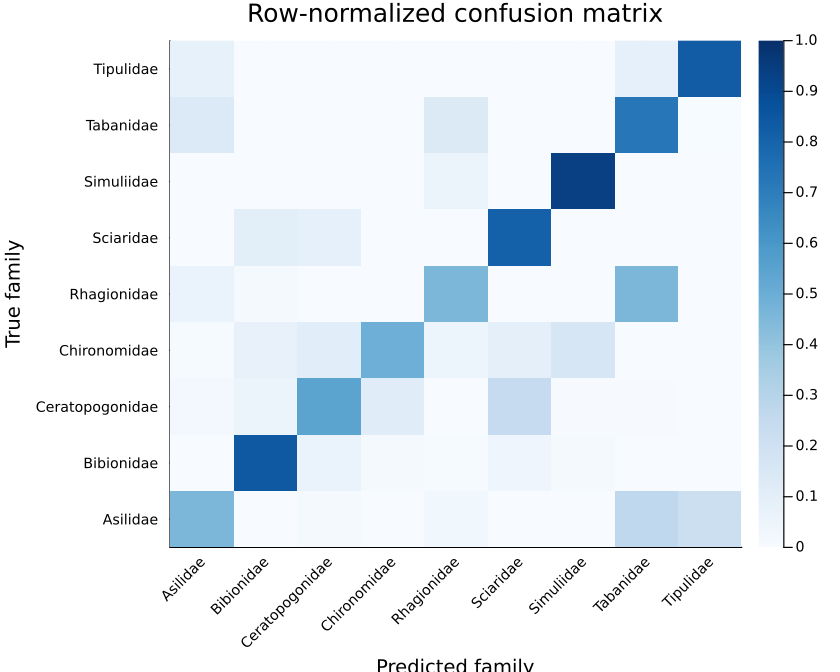

In [15]:
cm_result = confusion_matrix(cv_results.pooled_true, cv_results.pooled_pred)
classes = cm_result.classes
cm_counts = cm_result.matrix
cm_normalized = zeros(Float64, size(cm_counts))
row_totals = vec(sum(cm_counts, dims = 2))

for i in axes(cm_counts, 1)
    if row_totals[i] > 0
        cm_normalized[i, :] = cm_counts[i, :] ./ row_totals[i]
    end
end

heatmap(
    cm_normalized,
    xticks = (1:length(classes), classes),
    yticks = (1:length(classes), classes),
    xlabel = "Predicted family",
    ylabel = "True family",
    title = "Row-normalized confusion matrix",
    color = :Blues,
    clims = (0, 1),
    xrotation = 45,
    size = (700, 560),
)

### Feature importance

Feature importance is descriptive. It is computed from balanced bootstrap trees fit on the full feature matrix, so it should be read as a guide to which topological summaries the Random Forest uses, not as an additional estimate of held-out performance.

In [16]:
rng_imp = MersenneTwister(RNG_SEED)
n_subfeatures_imp = max(1, round(Int, sqrt(size(X_features, 2))))
feature_importance = zeros(size(X_features, 2))

for _ in 1:RF_N_TREES
    boot_idx = balanced_bootstrap_indices(labels; rng = rng_imp)
    tree = build_tree(
        labels[boot_idx],
        X_features[boot_idx, :],
        n_subfeatures_imp,
        RF_MAX_DEPTH,
        RF_MIN_SAMPLES_LEAF,
        2,
        0.0;
        loss = DecisionTree.util.gini,
        rng = rng_imp,
        impurity_importance = true,
    )
    feature_importance .+= DecisionTree.impurity_importance(tree; normalize = false)
end

if maximum(feature_importance) > 0
    feature_importance ./= maximum(feature_importance)
end

importance_df = DataFrame(
    feature = feature_names,
    importance = feature_importance,
)
sort!(importance_df, :importance, rev = true)
top_importance = first(filter(:importance => >(0.0), importance_df), min(15, nrow(importance_df)))
top_importance


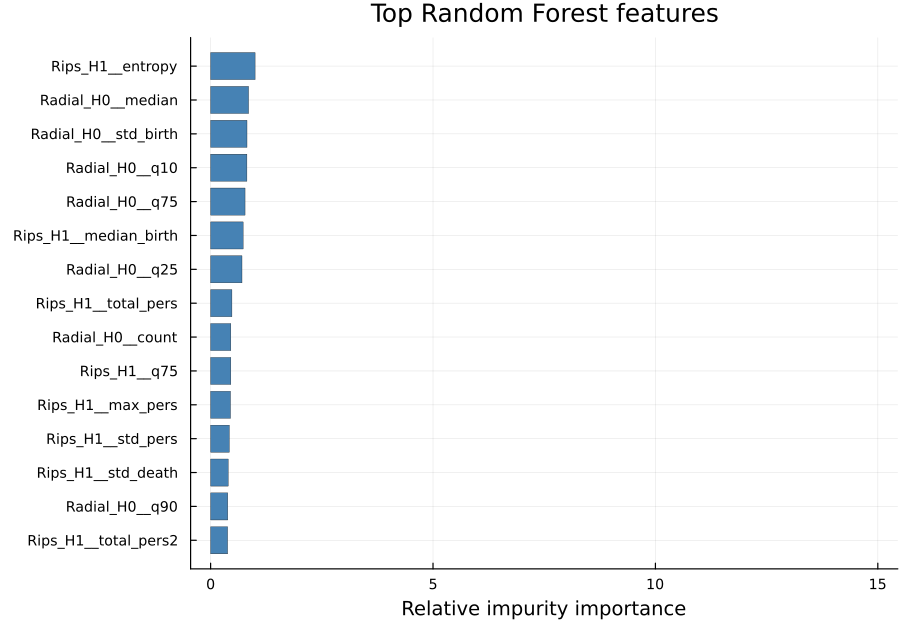

In [17]:
if nrow(top_importance) == 0
    plot(title = "Random Forest feature importance", legend = false)
else
    ord = sortperm(top_importance.importance)
    bar(
        1:length(ord),
        top_importance.importance[ord],
        orientation = :horizontal,
        yticks = (1:length(ord), top_importance.feature[ord]),
        xlabel = "Relative impurity importance",
        title = "Top Random Forest features",
        legend = false,
        color = :steelblue,
        linecolor = :black,
        linewidth = 0.25,
        size = (760, 520),
    )
end

### Essential feature reduction

To identify a compact feature set for biological interpretation, we use the Random Forest importance ranking as a reduction path. We evaluate nested subsets of the top-ranked features and select the smallest subset whose screening performance remains within one percentage point of the full 34-feature model for both pooled accuracy and pooled macro-F1. The selected subset is then re-evaluated with the full repeated stratified 3-fold CV configuration.

This procedure is intended to rank features for interpretation. It should not be treated as an independent performance estimate because the feature ranking is learned from the same dataset.

In [18]:
function evaluate_ranked_feature_subsets(
    X::Matrix,
    labels::Vector{String},
    ordered_feature_idx::Vector{Int};
    candidate_sizes::Vector{Int},
    k::Int,
    repeats::Int,
    n_trees::Int,
    max_depth::Int,
    min_samples_leaf::Int,
    rng_seed::Int,
)
    rows = NamedTuple[]
    for n_features in candidate_sizes
        feature_idx = ordered_feature_idx[1:n_features]
        result = repeated_stratified_rf_cv(
            X[:, feature_idx],
            labels;
            k = k,
            repeats = repeats,
            n_trees = n_trees,
            max_depth = max_depth,
            min_samples_leaf = min_samples_leaf,
            rng_seed = rng_seed + 50_000 + n_features,
        )
        push!(rows, (
            n_features = n_features,
            accuracy = result.pooled_metrics.accuracy,
            macro_f1 = result.pooled_metrics.macro_f1,
            macro_recall = result.pooled_metrics.balanced_accuracy,
        ))
    end
    DataFrame(rows)
end

ordered_feature_idx = sortperm(feature_importance, rev = true)
candidate_sizes = collect(1:length(feature_names))

feature_reduction_screen = evaluate_ranked_feature_subsets(
    X_features,
    labels,
    ordered_feature_idx;
    candidate_sizes = candidate_sizes,
    k = CV_K,
    repeats = FEATURE_SCREEN_REPEATS,
    n_trees = FEATURE_SCREEN_N_TREES,
    max_depth = RF_MAX_DEPTH,
    min_samples_leaf = RF_MIN_SAMPLES_LEAF,
    rng_seed = RNG_SEED,
)

full_screen = feature_reduction_screen[feature_reduction_screen.n_features .== length(feature_names), :]
accuracy_threshold = only(full_screen.accuracy) - FEATURE_PERFORMANCE_TOLERANCE
macro_f1_threshold = only(full_screen.macro_f1) - FEATURE_PERFORMANCE_TOLERANCE

eligible_feature_counts = feature_reduction_screen.n_features[
    (feature_reduction_screen.accuracy .>= accuracy_threshold) .&
    (feature_reduction_screen.macro_f1 .>= macro_f1_threshold)
]

essential_n_features = isempty(eligible_feature_counts) ? length(feature_names) : minimum(eligible_feature_counts)
essential_feature_idx = ordered_feature_idx[1:essential_n_features]

essential_cv_results = repeated_stratified_rf_cv(
    X_features[:, essential_feature_idx],
    labels;
    k = CV_K,
    repeats = CV_REPEATS,
    n_trees = RF_N_TREES,
    max_depth = RF_MAX_DEPTH,
    min_samples_leaf = RF_MIN_SAMPLES_LEAF,
    rng_seed = RNG_SEED + 100_000,
)

feature_reduction_summary = DataFrame(
    feature_set = ["All features", "Essential feature set"],
    n_features = [length(feature_names), essential_n_features],
    accuracy_percent = round.([
        cv_results.pooled_metrics.accuracy,
        essential_cv_results.pooled_metrics.accuracy,
    ] .* 100, digits = 1),
    macro_f1_percent = round.([
        cv_results.pooled_metrics.macro_f1,
        essential_cv_results.pooled_metrics.macro_f1,
    ] .* 100, digits = 1),
    macro_recall_percent = round.([
        cv_results.pooled_metrics.balanced_accuracy,
        essential_cv_results.pooled_metrics.balanced_accuracy,
    ] .* 100, digits = 1),
)
feature_reduction_summary

In [19]:
essential_feature_parts = split.(feature_names[essential_feature_idx], "__")
essential_features_df = DataFrame(
    rank = 1:essential_n_features,
    block = getindex.(essential_feature_parts, 1),
    statistic = getindex.(essential_feature_parts, 2),
    relative_importance = round.(feature_importance[essential_feature_idx], digits = 3),
)
essential_features_df


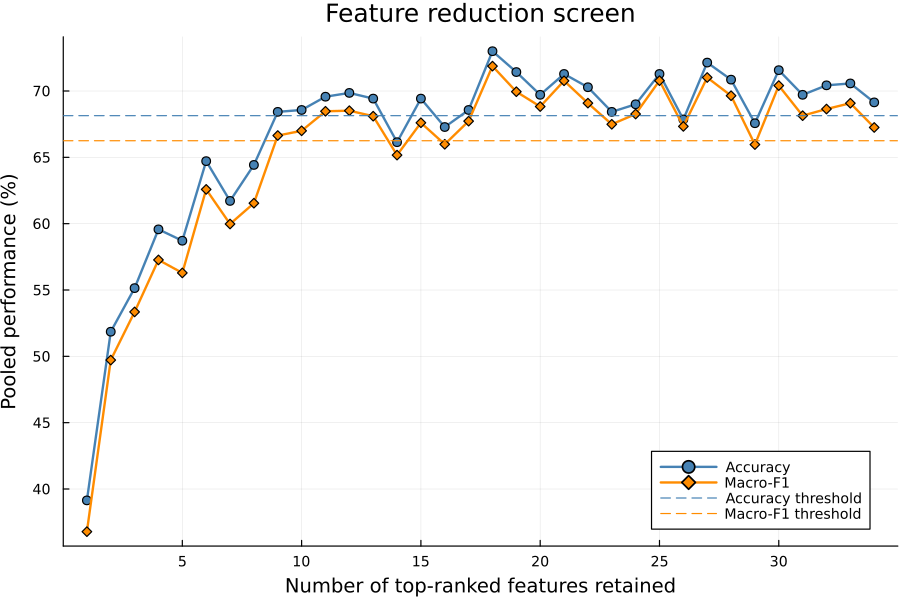

In [20]:
feature_reduction_plot_df = copy(feature_reduction_screen)
plot(
    feature_reduction_plot_df.n_features,
    feature_reduction_plot_df.accuracy .* 100,
    label = "Accuracy",
    xlabel = "Number of top-ranked features retained",
    ylabel = "Pooled performance (%)",
    title = "Feature reduction screen",
    color = :steelblue,
    linewidth = 2,
    marker = :circle,
    legend = :bottomright,
    size = (760, 500),
)
plot!(
    feature_reduction_plot_df.n_features,
    feature_reduction_plot_df.macro_f1 .* 100,
    label = "Macro-F1",
    color = :darkorange,
    linewidth = 2,
    marker = :diamond,
)
hline!(
    [accuracy_threshold * 100],
    label = "Accuracy threshold",
    color = :steelblue,
    linestyle = :dash,
    linewidth = 1,
)
hline!(
    [macro_f1_threshold * 100],
    label = "Macro-F1 threshold",
    color = :darkorange,
    linestyle = :dash,
    linewidth = 1,
)

## Discussion

These results suggest that compact topological summaries of wing venation contain family-level signal. The two retained filtrations capture different information: Vietoris-Rips H1 summarizes global loop structure in the vein network, while radial H0 summarizes how connected vein components organize from the center of the wing outward.

The validation design is intentionally conservative for the current dataset. Because the dataset contains only 70 specimens and the family counts are uneven, the primary summaries are macro-F1 and macro-recall rather than overall correct rate. Repeating the stratified 3-fold split 30 times reduces dependence on a single partition and gives a clearer view of which families are stable or ambiguous.

The feature-reduction results provide a candidate set of topological summaries for biological follow-up. Features retained in the essential set should be inspected against wing venation traits, including loop structure, the number of persistent components, and the scale at which vein components merge under the radial filtration.

The main practical limitation is still sample size. Several families have fewer than ten specimens, so family-level recall should be interpreted as provisional. Image quality, binarization, and connectivity correction also affect the persistence diagrams. Follow-up work should add taxonomic context, literature references, and a biological interpretation of the retained topological summaries.